In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

In [15]:

df = pd.DataFrame(x, columns=iris.feature_names)
print(df.head())

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2


In [14]:
iris = load_iris()
x = iris.data

In [17]:
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

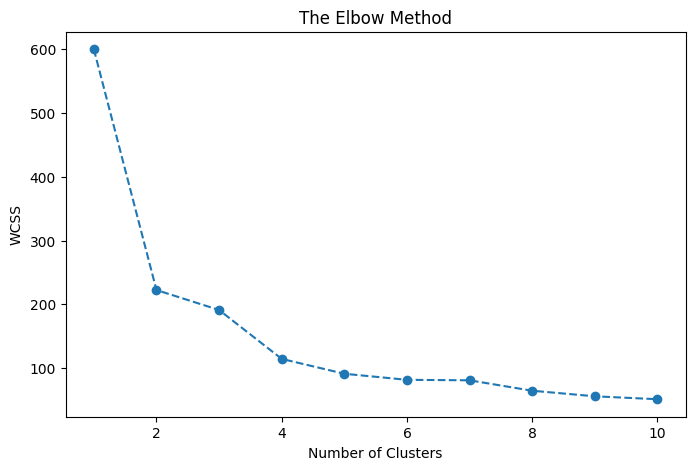

In [18]:
wcss=[]


for i in range(1,11):
  kmeans=KMeans(n_clusters=i,init='k-means++',random_state=42)
  kmeans.fit(x_scaled)
  wcss.append(kmeans.inertia_)


plt.figure(figsize=(8,5))
plt.plot(range(1,11),wcss,marker='o',linestyle='--')
plt.title('The Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.show()

In [26]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = kmeans.fit_predict(x_scaled)
df['cluster'] = clusters
score = silhouette_score(x_scaled, clusters)
print("Silhouette Score:", score)

Silhouette Score: 0.45994823920518635


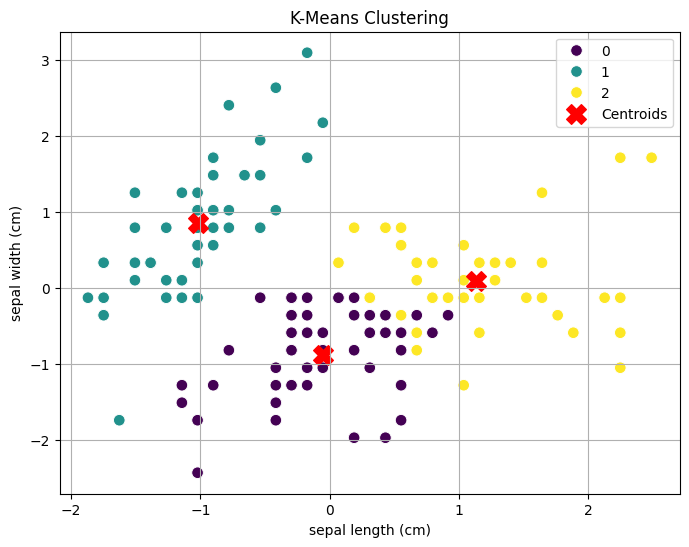

In [30]:
feature_names = iris.feature_names

plt.figure(figsize=(8, 6))

sns.scatterplot(
    x=x_scaled[:, 0],
    y=x_scaled[:, 1],
    hue=clusters,
    palette="viridis",
    s=70
)


centroids = kmeans.cluster_centers_

plt.scatter(
    centroids[:, 0],
    centroids[:, 1],
    marker="X",
    s=200,
    c="red",
    label="Centroids"
)

plt.title("K-Means Clustering")
plt.xlabel(feature_names[0])
plt.ylabel(feature_names[1])
plt.legend()
plt.grid(True)

plt.show()